# (26) EAT method – bias of moments plot (theory)

**Project: `_PoissonGradEstim`**

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

# dtype = torch.bfloat16 # half the size of float32
dtype = torch.float32

print(f"device: {device}, dtype: {dtype}  ———  host: {os.uname().nodename}")

device: cuda:0, dtype: torch.float32  ———  host: mach

## Make fig dir

In [3]:
fig_dir = fig_base_dir / f'{project_name}_figs-(2026_01_28)'
fig_dir.mkdir(exist_ok=True)

os.listdir(str(fig_dir))

['dist_consistency_wasser.pdf',
 'soft_indicators.pdf',
 'phi.pdf',
 'dist_wasser_lam-[2,20,100].pdf',
 'grad_analysis_all_rates.pdf',
 'dist_consistency_bias.pdf',
 'dist_moments_lam-[2,20,100].pdf',
 'dist_moments_theory.pdf',
 'grad_analysis_lam-20.pdf',
 'dist_consistency_ratio.pdf',
 'grad_analysis_raw_lam-20.pdf']

## Theorey fun

In [4]:
# Helper functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softplus(x):
    return np.log(1 + np.exp(x))

# Sigmoid quantities
def c_sigmoid(tau):
    return tau * softplus(1/tau)

def v_sigmoid(tau):
    return tau * (softplus(1/tau) - sigmoid(1/tau))

def F_sigmoid(tau):
    return v_sigmoid(tau) / c_sigmoid(tau)

# Cubic quantities
def c_cubic(tau):
    result = np.ones_like(tau)
    mask = tau > 1
    beta = (1 + tau[mask]) / (2 * tau[mask])
    result[mask] = tau[mask] * beta**3 * (2 - beta)
    return result

def v_cubic(tau):
    result = 1 - 9*tau/35
    mask = tau > 1
    beta = (1 + tau[mask]) / (2 * tau[mask])
    result[mask] = tau[mask] * (18*beta**5/5 - 4*beta**6 + 8*beta**7/7)
    return result

def F_cubic(tau):
    return v_cubic(tau) / c_cubic(tau)

## Fig fun

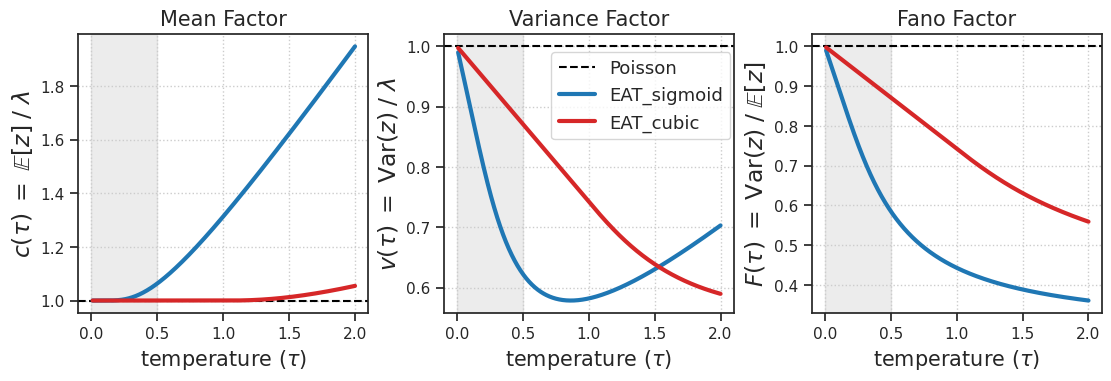

In [5]:
# Set up tau range
tau = np.linspace(0.01, 2.0, 1000)

# Create figure with 3 subplots
fig, axes = create_figure(1, 3, figsize=(11, 3.7))

for ax in axes.flat:
    ax.axvspan(0, 0.5, alpha=0.15, color='gray', zorder=0)

# Plot c(tau) - Mean factor
ax1 = axes[0]
ax1.axhline(y=1, color='k', linestyle='--', alpha=1.0, label='Poisson')
ax1.plot(tau, c_sigmoid(tau), 'C0', linewidth=3, label='EAT_sigmoid')
ax1.plot(tau, c_cubic(tau), 'C3', linewidth=3, label='EAT_cubic')

ax1.set_xlabel("temperature " + r"$(\tau)$", fontsize=15)
ax1.set_ylabel(r'$c(\tau) \;=\; \mathbb{E}[z] \;/\; \lambda$', fontsize=17)
ax1.set_title('Mean Factor', fontsize=15)
# ax1.legend(loc='upper left')
# ax1.grid(True, alpha=0.3)
# ax1.set_xlim(0, 1.5)
# ax1.set_ylim(0.9, 1.6)

# Plot v(tau) - Variance factor
ax2 = axes[1]
ax2.axhline(y=1, color='k', linestyle='--', alpha=1.0, label='Poisson')
ax2.plot(tau, v_sigmoid(tau), 'C0', linewidth=3, label='EAT_sigmoid')
ax2.plot(tau, v_cubic(tau), 'C3', linewidth=3, label='EAT_cubic')

ax2.set_xlabel("temperature " + r"$(\tau)$", fontsize=15)
ax2.set_ylabel(r'$v(\tau) \;=\; \mathrm{Var}(z) \;/\; \lambda$', fontsize=17)
ax2.set_title('Variance Factor', fontsize=15)
ax2.legend(loc='best', fontsize=13)
# ax2.grid(True, alpha=0.3)
# ax2.set_xlim(0, 1.5)
# ax2.set_ylim(0.4, 1.05)

# Plot F(tau) - Fano factor
ax3 = axes[2]
ax3.axhline(y=1, color='k', linestyle='--', alpha=1.0, label='Poisson')
ax3.plot(tau, F_sigmoid(tau), 'C0', linewidth=3, label='EAT_sigmoid')
ax3.plot(tau, F_cubic(tau), 'C3', linewidth=3, label='EAT_cubic')

# ax3.axhspan(0.5, 1.0, alpha=0.1, color='green', label='Cortical range')
ax3.set_xlabel("temperature " + r"$(\tau)$", fontsize=15)
ax3.set_ylabel(r'$F(\tau) \;=\; \mathrm{Var}(z) \;/\; \mathbb{E}[z]$', fontsize=17)
ax3.set_title('Fano Factor', fontsize=15)
# ax3.legend(loc='upper right')
# ax3.grid(True, alpha=0.3)
# ax3.set_xlim(0, 1.5)
# ax3.set_ylim(0.3, 1.05)

move_legend(ax2, (0.34, 0.59))


add_grid(axes)

plt.show()

In [6]:
# fig.savefig(fig_dir / f'dist_moments_theory.pdf', bbox_inches='tight')

## cuibic vs sigmoid

In [21]:
def plot_soft_indicators(save_path=None):
    """
    Visualize sigmoid, cubic, and quintic smoothstep soft indicator functions,
    along with their first and second derivatives.
    """
    u = np.linspace(-6, 6, 2000)
    
    # Sigmoid
    sigmoid = 1 / (1 + np.exp(-u))
    
    # Sigmoid derivatives
    sigmoid_d1 = sigmoid * (1 - sigmoid)
    sigmoid_d2 = sigmoid_d1 * (1 - 2 * sigmoid)
    
    # Cubic smoothstep: f(w) = 3w^2 - 2w^3, where w = (u+1)/2
    def cubic_smoothstep(u):
        w = np.clip(0.5 * u + 0.5, 0, 1)
        return 3 * w**2 - 2 * w**3
    
    def cubic_smoothstep_d1(u):
        # df/du = df/dw * dw/du = (6w - 6w^2) * 0.5 = 3w(1-w) * 0.5
        # Simplifies to: 3(1 - u^2)/4 on [-1, 1]
        result = np.zeros_like(u)
        mask = (u >= -1) & (u <= 1)
        result[mask] = 3 * (1 - u[mask]**2) / 4
        return result
    
    def cubic_smoothstep_d2(u):
        # d²f/du² = -3u/2 on [-1, 1]
        result = np.zeros_like(u)
        mask = (u >= -1) & (u <= 1)
        result[mask] = -3 * u[mask] / 2
        return result
    
    # Quintic smoothstep: f(w) = 6w^5 - 15w^4 + 10w^3, where w = (u+1)/2
    def quintic_smoothstep(u):
        w = np.clip(0.5 * u + 0.5, 0, 1)
        return 6 * w**5 - 15 * w**4 + 10 * w**3
    
    def quintic_smoothstep_d1(u):
        # df/dw = 30w^4 - 60w^3 + 30w^2 = 30w^2(w-1)^2
        # df/du = df/dw * 0.5 = 15w^2(w-1)^2
        result = np.zeros_like(u)
        mask = (u >= -1) & (u <= 1)
        w = 0.5 * u[mask] + 0.5
        result[mask] = 15 * w**2 * (w - 1)**2
        return result
    
    def quintic_smoothstep_d2(u):
        # d²f/dw² = 120w^3 - 180w^2 + 60w = 60w(2w-1)(w-1)
        # d²f/du² = d²f/dw² * 0.25 = 15w(2w-1)(w-1)
        result = np.zeros_like(u)
        mask = (u >= -1) & (u <= 1)
        w = 0.5 * u[mask] + 0.5
        result[mask] = 15 * w * (2*w - 1) * (w - 1)
        return result
    
    cubic = cubic_smoothstep(u)
    cubic_d1 = cubic_smoothstep_d1(u)
    cubic_d2 = cubic_smoothstep_d2(u)
    
    quintic = quintic_smoothstep(u)
    quintic_d1 = quintic_smoothstep_d1(u)
    quintic_d2 = quintic_smoothstep_d2(u)
    
    # Hard indicator for reference
    hard = (u > 0).astype(float)
    
    fig, axes = create_figure(1, 2, figsize=(15, 6.0))
    
    # --- First subplot: original plot ---
    ax = axes[0]
    ax.plot(u, cubic, 'C3', linewidth=3, label='Cubic (C1)', zorder=3)
    ax.plot(u, quintic, 'C2', linewidth=3, label='Quintic (C2)', zorder=3)
    ax.plot(u, sigmoid, 'C0', linewidth=3, label=r'Sigmoid (C$^\infty$)', zorder=2)
    ax.plot(u, hard, 'k--', linewidth=1.5, alpha=0.7, label='Hard indicator', zorder=4)
    ax.axvline(x=-1, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5)
    
    ax.set_xlabel(r'$u$', fontsize=17)
    ax.set_ylabel(r'$f_{\mathrm{approx}}(u)$', fontsize=17)
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='lower right', fontsize=13)
    ax.set_title('Soft indicator functions', fontsize=13)
    ax.grid(alpha=0.5)
    
    # --- Second subplot: derivatives ---
    ax = axes[1]
    # First derivatives (solid)
    ax.plot(u, cubic_d1, 'C3', linewidth=3, label=r"Cubic $f'$", zorder=3)
    ax.plot(u, quintic_d1, 'C2', linewidth=3, label=r"Quintic $f'$", zorder=3)
    ax.plot(u, sigmoid_d1, 'C0', linewidth=3, label=r"Sigmoid $f'$", zorder=2)
    # Second derivatives (dashed)
    ax.plot(u, cubic_d2, 'C3', linewidth=3, linestyle='--', label=r"Cubic $f''$", zorder=3)
    ax.plot(u, quintic_d2, 'C2', linewidth=3, linestyle='--', label=r"Quintic $f''$", zorder=3)
    ax.plot(u, sigmoid_d2, 'C0', linewidth=3, linestyle='--', label=r"Sigmoid $f''$", zorder=2)
    ax.axvline(x=-1, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel(r'$u$', fontsize=17)
    ax.set_ylabel('Derivative value', fontsize=17)
    ax.set_xlim(-4.5, 4.5)
    ax.legend(loc='upper right', fontsize=11, ncol=2)
    ax.set_title('First and second derivatives', fontsize=13)
    ax.grid(alpha=0.5)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    return fig, axes

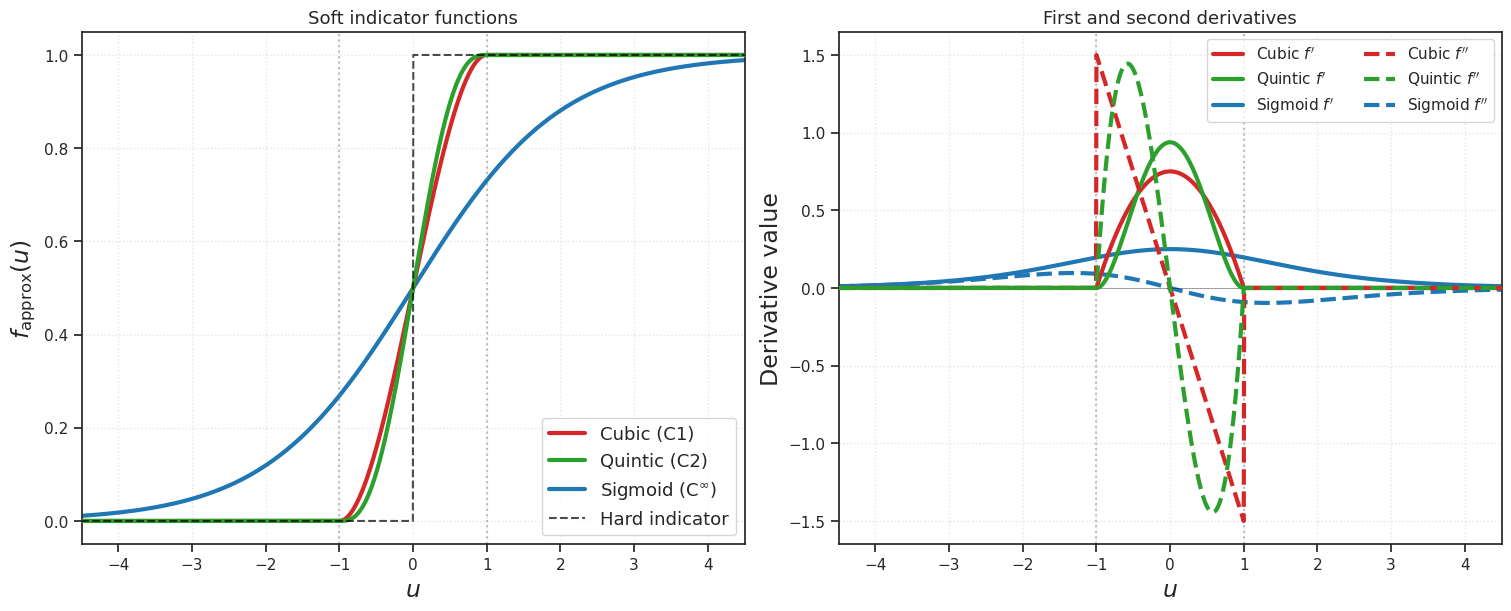

In [22]:
# plot_soft_indicators(fig_dir / 'soft_indicators.pdf');
plot_soft_indicators();